In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("C:/Users/Administrator/PythonProjects/discharge_queich/")

from pathlib import Path
import pandas as pd
from dataclasses import dataclass

from discharge_queich.configs import settings
from discharge_queich.utils.logger import logger

In [2]:
icon_settings = settings.ingestion.icon

## fetch_icon_refactor.py

In [3]:
from discharge_queich.jobs.icon.fetch_icon import (
    build_icon_download_dataclass,
    download_all_icon_file,
    fetch_icon
)

In [6]:
fetch_icon()

2026-07-14 16:48:53,350 | fetch_icon.py | INFO | [ICON PRECIP FORECAST] Saved icon-d2_germany_regular-lat-lon_single-level_2026071412_000_2d_tot_prec.grib2.bz2 to data\forecast_precip\icon_d2\12\compressed\icon-d2_germany_regular-lat-lon_single-level_2026071412_000_2d_tot_prec.grib2.bz2
2026-07-14 16:48:53,496 | fetch_icon.py | INFO | [ICON PRECIP FORECAST] Saved icon-d2_germany_regular-lat-lon_single-level_2026071412_001_2d_tot_prec.grib2.bz2 to data\forecast_precip\icon_d2\12\compressed\icon-d2_germany_regular-lat-lon_single-level_2026071412_001_2d_tot_prec.grib2.bz2
2026-07-14 16:48:53,610 | fetch_icon.py | INFO | [ICON PRECIP FORECAST] Saved icon-d2_germany_regular-lat-lon_single-level_2026071412_002_2d_tot_prec.grib2.bz2 to data\forecast_precip\icon_d2\12\compressed\icon-d2_germany_regular-lat-lon_single-level_2026071412_002_2d_tot_prec.grib2.bz2
2026-07-14 16:48:53,849 | fetch_icon.py | INFO | [ICON PRECIP FORECAST] Saved icon-d2_germany_regular-lat-lon_single-level_2026071412_00

# ingest_icon.py

In [28]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("C:/Users/Administrator/PythonProjects/discharge_queich/")

from dataclasses import dataclass
from pathlib import Path
import pandas as pd
import geopandas as gpd

from discharge_queich.configs import settings
from discharge_queich.jobs.icon.process_icon import build_precip_timeseries

from sqlalchemy import select, func
from sqlalchemy.orm import Session
from discharge_queich.database.db import SessionLocal, engine
from discharge_queich.database.models import IconPrecipForecastAllruns

catchment_settings = settings.ingestion.catchment
icon_settings = settings.ingestion.icon

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
input_dir=icon_settings.decompressed_dir
catchment_path=catchment_settings.catchment_path
clip_crs=icon_settings.clip_crs

In [16]:
@dataclass(slots=True)
class IconMetadata:
    file_path: str | Path
    file_name: str | Path
    run_time: pd.Timestamp
    lead_hour: int
    valid_time: pd.Timestamp


def parse_icon_filepath(filepath: str | Path) -> IconMetadata:
    
    filename = Path(filepath).stem
    split = str(filename).split("_")    
    
    run_time = pd.to_datetime(split[4], format="%Y%m%d%H")
    lead_hour = int(split[5])

    return IconMetadata(
        file_path=filepath,
        file_name=filename,
        run_time=run_time,
        lead_hour=lead_hour,
        valid_time=run_time + pd.Timedelta(hours=lead_hour),
    )
    

def get_local_metadata(input_dir: str | Path) -> pd.DataFrame:
    
    input_dir = Path(input_dir)
    file_paths = sorted(input_dir.glob("*.grib2"))

    rows = []
    
    for path in file_paths:
        temp = parse_icon_filepath(filepath=path)
        
        rows.append({
            "file_path": temp.file_path,
            "file_name": temp.file_name,
            "run_time": temp.run_time,
            "lead_hour": temp.lead_hour,
            "valid_time": temp.valid_time + pd.Timedelta(hours=temp.lead_hour)
        })

    return pd.DataFrame(rows)


def get_latest_runtime() -> pd.Timestamp | None:
    with SessionLocal() as session:
        
        stmt = (
            func.max(
                select(IconPrecipForecastAllruns.run_time)
                .scalar_subquery()
                )
            )
        
        result = session.execute(stmt)
        
        latest = result.scalar()
        
        if latest is None:
            return None

        return pd.Timestamp(latest)
    

def filter_icon_files(
    df: pd.DataFrame,
    timestamp: pd.Timestamp | None
    ) -> pd.DataFrame:
    
    if timestamp is None:
        return df
    
    df = df[df["timestamp"] >= timestamp]
    
    return df

In [29]:
decompressed_dir = icon_settings.decompressed_dirs[1]

df_meta = get_local_metadata(input_dir=decompressed_dir)
latest_ts = get_latest_runtime()

df_filter = filter_icon_files(df=df_meta, timestamp=latest_ts)
df_filter

,file_path,file_name,run_time,lead_hour,valid_time
0,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-13 03:00:00,0,2026-07-13 03:00:00
1,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-13 03:00:00,1,2026-07-13 05:00:00
2,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-13 03:00:00,2,2026-07-13 07:00:00
3,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-13 03:00:00,3,2026-07-13 09:00:00
4,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-13 03:00:00,4,2026-07-13 11:00:00
...,...,...,...,...,...
93,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-14 03:00:00,44,2026-07-17 19:00:00
94,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-14 03:00:00,45,2026-07-17 21:00:00
95,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-14 03:00:00,46,2026-07-17 23:00:00
96,data\forecast_precip\icon_d2\03\decompressed\i...,icon-d2_germany_regular-lat-lon_single-level_2...,2026-07-14 03:00:00,47,2026-07-18 01:00:00


In [ ]:
import xarray as xr

from discharge_queich.jobs.icon.process_icon import (
    extract_precip_timeseries,
    clip_to_catchment
    )

def build_precip_timeseries(
    input_dir: str | Path,
    catchment_path: str | Path,
    clip_crs: str,
    ):
    # ) -> pd.DataFrame:
    
    input_dir = Path(input_dir)
    
    file_paths = sorted(input_dir.glob("*.grib2"))
    
    catchment = gpd.read_file(catchment_path).to_crs(clip_crs)
    
    dfs: list[pd.DataFrame] = []
    
    # --- Open dataset and extract ---
    for file in file_paths:
        ds = None
        
        file_metadata = parse_icon_filepath(filepath=file)
        
        try:
            ds = xr.open_dataset(
                file, 
                engine="cfgrib",
                backend_kwargs={"indexpath": ""},
                )

            precip_crop = clip_to_catchment(
                dataset=ds,
                catchment=catchment,
                crs=clip_crs
            )

            df_precip = extract_precip_timeseries(
                precip=precip_crop,
                run_time=file_metadata.run_time
                )
            
            dfs.append(df_precip)
        
        
        except Exception:
            logger.exception("Failed to process ICON GRIB file: %s", file)
            continue
        
        finally:
            if ds is not None:
                
                ds.close()
    if not dfs:
        raise ValueError("No valid precipitation files processed.") 
    
    df = pd.concat(dfs)
    
    df = df.set_index("timestamp")
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="last")]
    
    df["precip_mean"] = (
        df.groupby("run_time")["precip_cum_mean"]
        .diff()
        .fillna(df["precip_cum_mean"])
    )
    
    df = df.drop(columns=["precip_cum_mean"])
    
    return df

In [139]:
# from discharge_queich.jobs.icon.process_icon import build_precip_timeseries

df = build_precip_timeseries(
    input_dir=decompressed_dir,
    catchment_path=catchment_settings.catchment_path,
    clip_crs=icon_settings.clip_crs
)

In [140]:
df

,run_time,precip_cum_mean,precip_mean
timestamp,,,
2026-07-13 03:00:00,2026-07-13 03:00:00,0.000000,0.0
2026-07-13 03:15:00,2026-07-13 03:00:00,0.000000,0.0
2026-07-13 03:30:00,2026-07-13 03:00:00,0.000000,0.0
2026-07-13 03:45:00,2026-07-13 03:00:00,0.000000,0.0
2026-07-13 04:00:00,2026-07-13 03:00:00,0.000000,0.0
...,...,...,...
2026-07-16 02:00:00,2026-07-14 03:00:00,4.763388,0.0
2026-07-16 02:15:00,2026-07-14 03:00:00,4.763388,0.0
2026-07-16 02:30:00,2026-07-14 03:00:00,4.763388,0.0


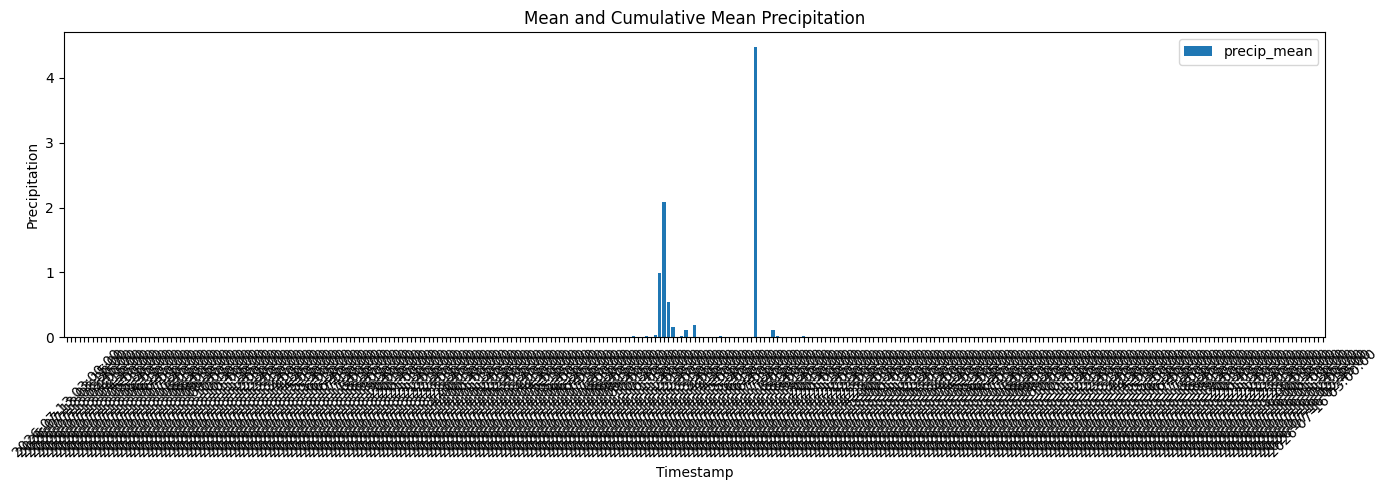

In [141]:
import matplotlib.pyplot as plt

ax = df[["precip_mean"]].plot(
# ax = df[["precip_cum_mean"]].plot(
    kind="bar",
    figsize=(14, 5),
    width=0.8,
)

ax.set_xlabel("Timestamp")
ax.set_ylabel("Precipitation")
ax.set_title("Mean and Cumulative Mean Precipitation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='timestamp'>

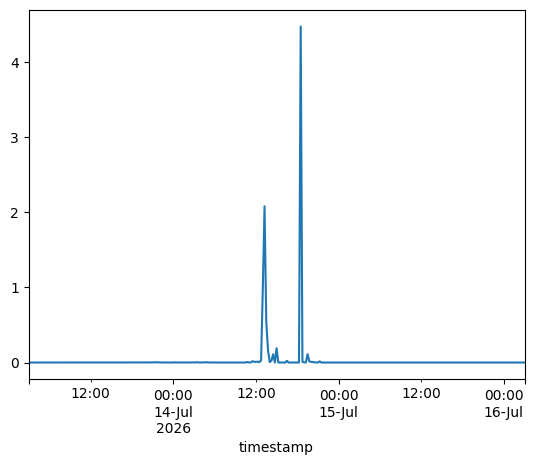

In [ ]:
df["precip_mean"].plot()

In [61]:
import xarray as xr

file = df_filter["file_path"].iloc[1]
run_time = df_filter["run_time"].iloc[1]
catchment_path = catchment_settings.catchment_path
clip_crs = icon_settings.clip_crs

catchment = gpd.read_file(catchment_path).to_crs(clip_crs)

print(Path(file).stem)

ds = xr.open_dataset(
    file, 
    engine="cfgrib",
    backend_kwargs={"indexpath": ""},
    )

precip_crop = clip_to_catchment(
    dataset=ds,
    catchment=catchment,
    crs=clip_crs
)

extract_precip_timeseries(precip=ds, run_time=run_time)

icon-d2_germany_regular-lat-lon_single-level_2026071303_001_2d_tot_prec


AttributeError: 'Dataset' object has no attribute 'ndim'

<xarray.Dataset> Size: 96B
Dimensions:     (step: 4)
Coordinates:
    time        datetime64[ns] 8B ...
  * step        (step) timedelta64[ns] 32B 01:00:00 01:15:00 01:30:00 01:45:00
    surface     float64 8B ...
    valid_time  (step) datetime64[ns] 32B 2026-05-17T01:00:00 ... 2026-05-17T...
Data variables:
    tp          (step) float32 16B 0.03477 0.04315 0.05166 0.06028

In [23]:
df_precip_mean = build_precip_timeseries(
        input_dir=icon_settings.decompressed_dir,
        catchment_path=catchment_settings.catchment_path,
        clip_crs=icon_settings.clip_crs
    )

df_precip_mean

KeyboardInterrupt: 